# Artifial Neural Networks

## Import Split

In [1]:
from util import generate_train_test_split

X_train, X_test, y_train, y_test = generate_train_test_split()


Before SMOTE:
label
0    619054
1    213397
Name: count, dtype: int64

After SMOTE:
label
0    619054
1    619054
Name: count, dtype: int64


## Scale Features

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


## ANN Implementation

In [4]:
from sklearn.neural_network import MLPClassifier

my_ANN1 = MLPClassifier(
    hidden_layer_sizes=(20, 10),   
    activation="logistic",         
    solver="adam",
    alpha=1e-5,
    learning_rate_init=0.001,
    max_iter=500,
    tol=1e-4,
    random_state=1,
    verbose=True
)

my_ANN1.fit(X_train_s, y_train)

Iteration 1, loss = 0.51870863
Iteration 2, loss = 0.41592766
Iteration 3, loss = 0.38365476
Iteration 4, loss = 0.36614880
Iteration 5, loss = 0.35606005
Iteration 6, loss = 0.34890529
Iteration 7, loss = 0.34282009
Iteration 8, loss = 0.33682621
Iteration 9, loss = 0.33050860
Iteration 10, loss = 0.32393374
Iteration 11, loss = 0.31655694
Iteration 12, loss = 0.30897188
Iteration 13, loss = 0.30075169
Iteration 14, loss = 0.29221637
Iteration 15, loss = 0.28380294
Iteration 16, loss = 0.27579520
Iteration 17, loss = 0.26834636
Iteration 18, loss = 0.26166589
Iteration 19, loss = 0.25567055
Iteration 20, loss = 0.25044404
Iteration 21, loss = 0.24572038
Iteration 22, loss = 0.24158255
Iteration 23, loss = 0.23782282
Iteration 24, loss = 0.23447340
Iteration 25, loss = 0.23147292
Iteration 26, loss = 0.22874374
Iteration 27, loss = 0.22640943
Iteration 28, loss = 0.22410978
Iteration 29, loss = 0.22211017
Iteration 30, loss = 0.22025479
Iteration 31, loss = 0.21857000
Iteration 32, los

,hidden_layer_sizes,"(20, ...)"
,activation,'logistic'
,solver,'adam'
,alpha,1e-05
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,1


In [5]:
my_ANN2 = MLPClassifier(
    hidden_layer_sizes=(64,32,16) ,  
    activation="relu",         
    solver="adam",
    alpha=1e-5,
    learning_rate_init=0.01,
    max_iter=300,
    tol=1e-4,
    random_state=10,
    verbose = True
)
my_ANN2.fit(X_train_s, y_train)

Iteration 1, loss = 0.28628953
Iteration 2, loss = 0.19014587
Iteration 3, loss = 0.17861566
Iteration 4, loss = 0.17351088
Iteration 5, loss = 0.17009762
Iteration 6, loss = 0.16762108
Iteration 7, loss = 0.16514937
Iteration 8, loss = 0.16324506
Iteration 9, loss = 0.16145747
Iteration 10, loss = 0.16007781
Iteration 11, loss = 0.15882067
Iteration 12, loss = 0.15760972
Iteration 13, loss = 0.15689380
Iteration 14, loss = 0.15608680
Iteration 15, loss = 0.15507527
Iteration 16, loss = 0.15473039
Iteration 17, loss = 0.15397945
Iteration 18, loss = 0.15362477
Iteration 19, loss = 0.15332345
Iteration 20, loss = 0.15222188
Iteration 21, loss = 0.15243044
Iteration 22, loss = 0.15158996
Iteration 23, loss = 0.15137463
Iteration 24, loss = 0.15127971
Iteration 25, loss = 0.15055814
Iteration 26, loss = 0.15059382
Iteration 27, loss = 0.15018100
Iteration 28, loss = 0.14985725
Iteration 29, loss = 0.14987956
Iteration 30, loss = 0.14905223
Iteration 31, loss = 0.14934827
Iteration 32, los

,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,1e-05
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,10


## Evaluations

### ANN1 Vs ANN2 Comparison

In [6]:
from sklearn.metrics import roc_auc_score, classification_report

# ANN1
y1_proba = my_ANN1.predict_proba(X_test_s)[:, 1]
y1_pred = my_ANN1.predict(X_test_s)

# ANN2
y2_proba = my_ANN2.predict_proba(X_test_s)[:, 1]
y2_pred = my_ANN2.predict(X_test_s)

In [7]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# ANN2 predictions
y_proba = my_ANN2.predict_proba(X_test_s)[:, 1]
y_pred  = my_ANN2.predict(X_test_s)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


ROC-AUC: 0.9826308923300652
              precision    recall  f1-score   support

           0       0.97      0.96      0.96    154764
           1       0.88      0.91      0.89     53349

    accuracy                           0.95    208113
   macro avg       0.92      0.93      0.93    208113
weighted avg       0.95      0.95      0.95    208113

Confusion matrix:
 [[148037   6727]
 [  4719  48630]]


### Heatmap

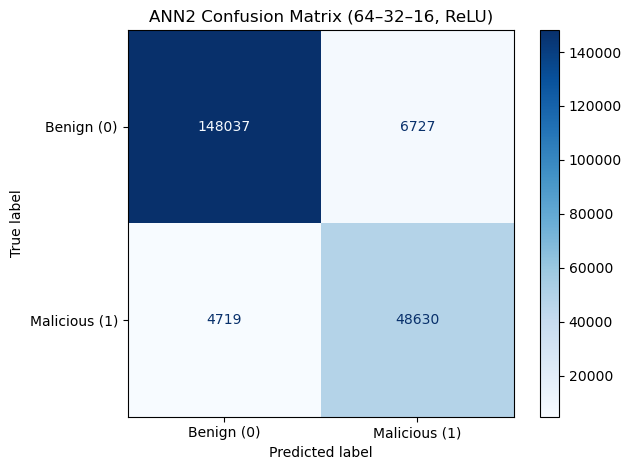

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y2_pred,
    display_labels=["Benign (0)", "Malicious (1)"],
    cmap="Blues",
    values_format="d"
)
plt.title("ANN2 Confusion Matrix (64–32–16, ReLU)")
plt.tight_layout()
plt.show()


### ROC

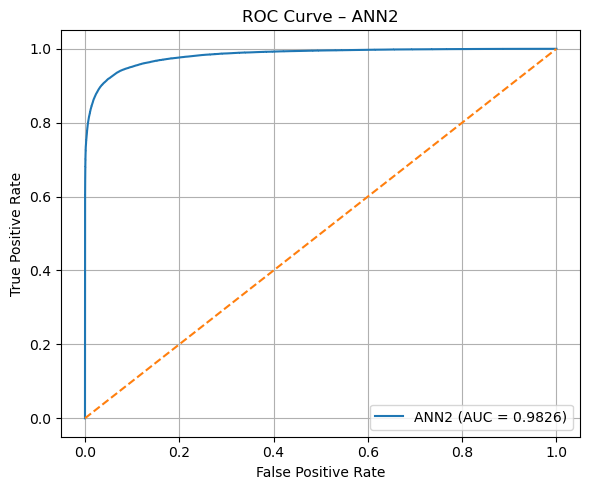

In [9]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y2_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ANN2 (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – ANN2")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Train

In [10]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Train predictions
y_train_proba = my_ANN2.predict_proba(X_train_s)[:, 1]
y_train_pred  = my_ANN2.predict(X_train_s)

print("TRAIN CONFUSION MATRIX")
print(confusion_matrix(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred, digits=4))
print("Train ROC AUC:", roc_auc_score(y_train, y_train_proba))

TRAIN CONFUSION MATRIX
[[593022  26032]
 [ 42322 576732]]
              precision    recall  f1-score   support

           0     0.9334    0.9579    0.9455    619054
           1     0.9568    0.9316    0.9441    619054

    accuracy                         0.9448   1238108
   macro avg     0.9451    0.9448    0.9448   1238108
weighted avg     0.9451    0.9448    0.9448   1238108

Train ROC AUC: 0.9881875148819957


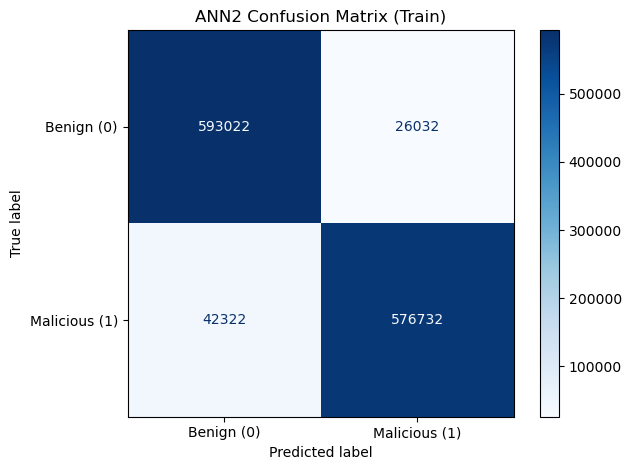

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred,
    display_labels=["Benign (0)", "Malicious (1)"],
    cmap="Blues",
    values_format="d"
)
plt.title("ANN2 Confusion Matrix (Train)")
plt.tight_layout()
plt.show()

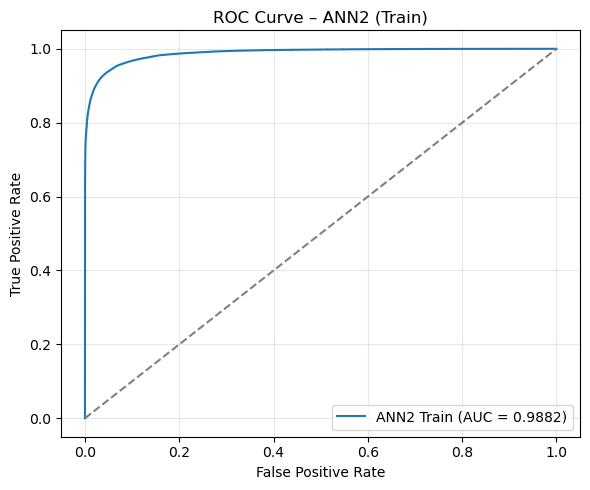

In [12]:
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

plt.figure(figsize=(6,5))
plt.plot(fpr_train, tpr_train, label=f"ANN2 Train (AUC = {roc_auc_train:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – ANN2 (Train)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()